# Usage

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import lostinmsh as lsm

plt.rcParams.update({"font.size": 15})

## Define the polygon

First we need to define the polygon from its vertices given as a sequence of 2d points and we also need to provide a name.

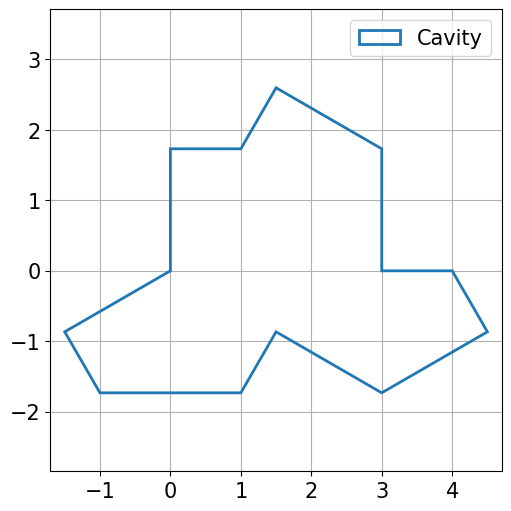

In [2]:
vertices = [
    (0, 0),
    (0, np.sqrt(3)),
    (1, np.sqrt(3)),
    (3 / 2, 3 * np.sqrt(3) / 2),
    (3, np.sqrt(3)),
    (3, 0),
    (4, 0),
    (9 / 2, -np.sqrt(3) / 2),
    (3, -np.sqrt(3)),
    (3 / 2, -np.sqrt(3) / 2),
    (1, -np.sqrt(3)),
    (-1, -np.sqrt(3)),
    (-3 / 2, -np.sqrt(3) / 2),
]
polygon = lsm.Polygon.from_vertices(vertices, "Cavity")

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
_ = lsm.plot_polygon(polygon, ax=ax)

## Define the geometry

Then, we need to define the geometry from a polygon and a border.
Two type of borders are implemented Circular and Rectangular borders without with a PML.
The border can be given explicitly.

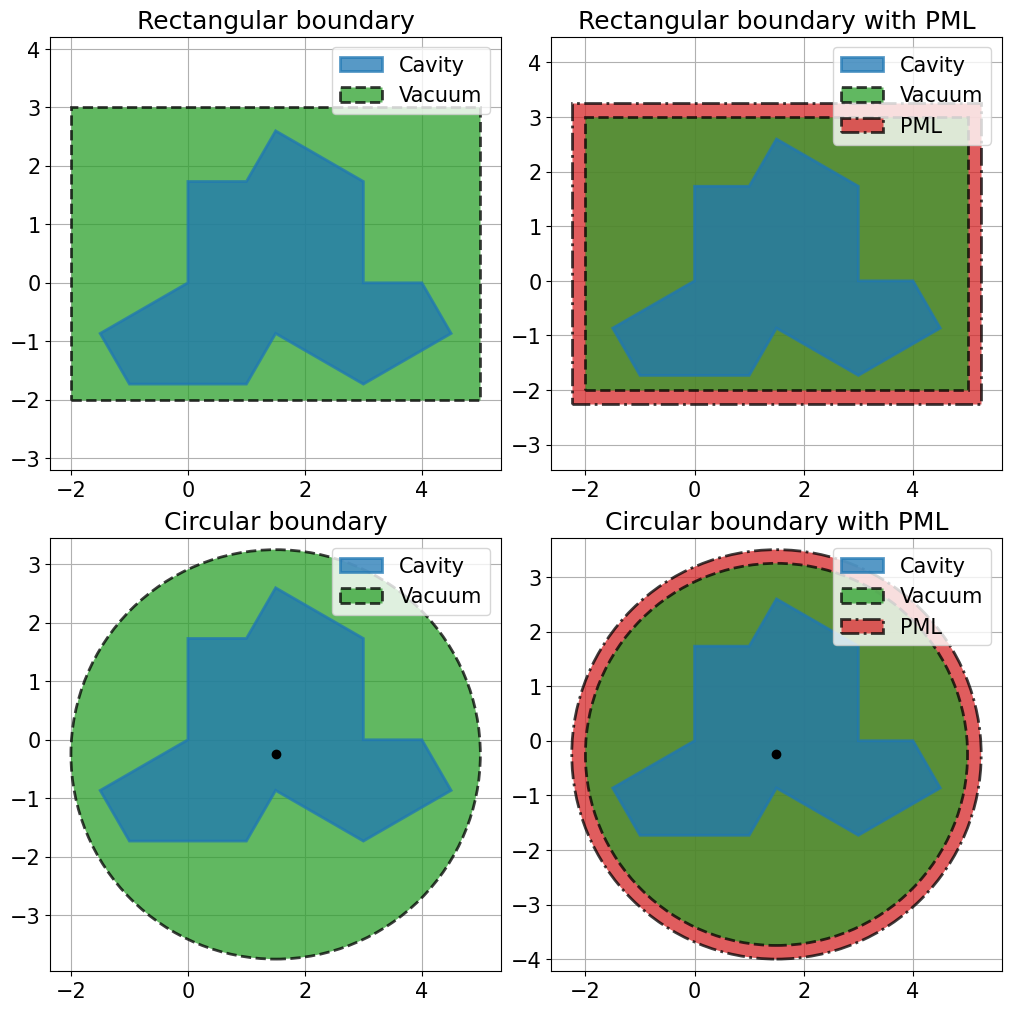

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), layout="constrained")

axs[0, 0].set_title("Rectangular boundary")
border = lsm.RectangularBoundary(
    corner_low=(-2, -2), corner_high=(5, 3), background_name="Vacuum"
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[0, 0])

axs[0, 1].set_title("Rectangular boundary with PML")
border = lsm.RectangularBoundary(
    corner_low=(-2, -2),
    corner_high=(5, 3),
    background_name="Vacuum",
    thickness=0.25,
    thickness_name="PML",
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[0, 1])

axs[1, 0].set_title("Circular boundary")
border = lsm.CircularBoundary(center=(1.5, -0.25), radius=3.5, background_name="Vacuum")
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[1, 0])

axs[1, 1].set_title("Circular boundary with PML")
border = lsm.CircularBoundary(
    center=(1.5, -0.25),
    radius=3.5,
    background_name="Vacuum",
    thickness=0.25,
    thickness_name="PML",
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[1, 1])

Or the border can be computed automaticaly.

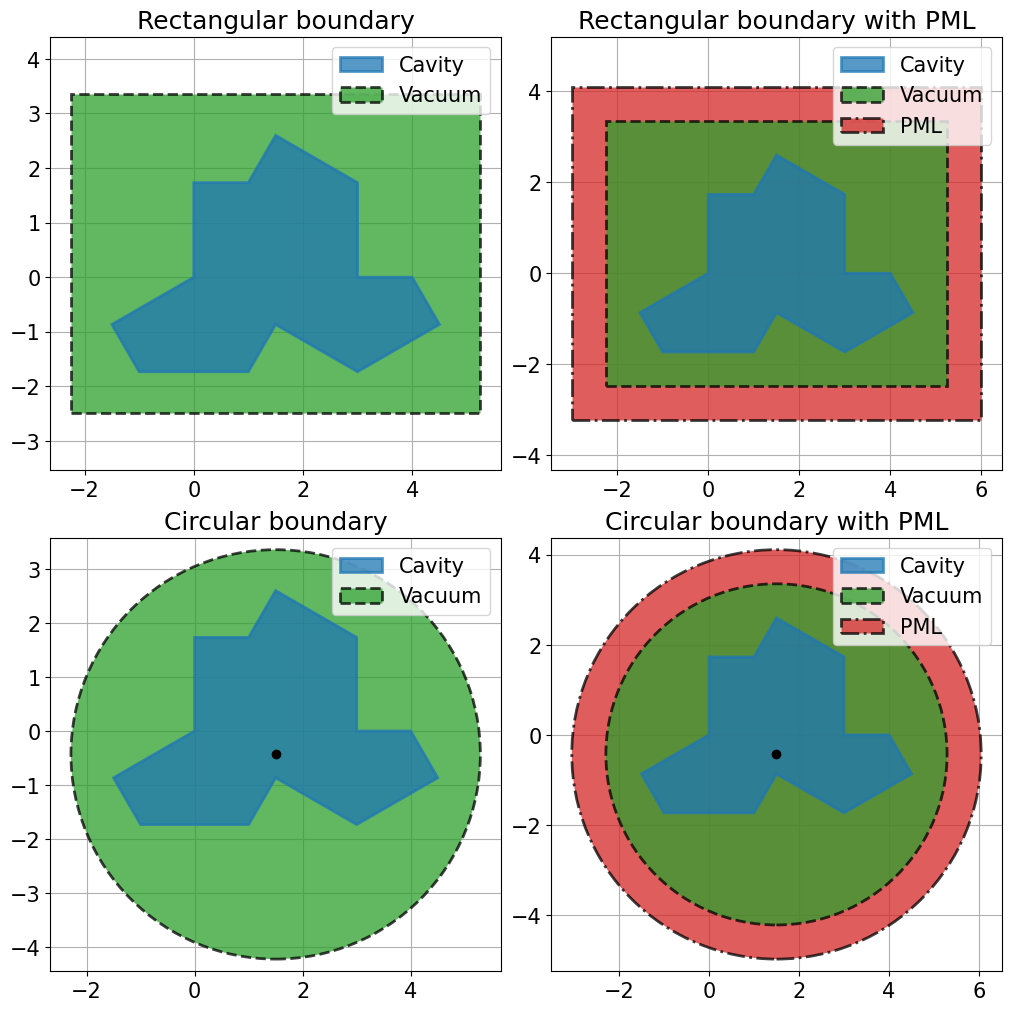

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), layout="constrained")

axs[0, 0].set_title("Rectangular boundary")
border = lsm.rectangular_boundary(
    polygons=[polygon], inner_factor=0.5, background_name="Vacuum"
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[0, 0])

axs[0, 1].set_title("Rectangular boundary with PML")
border = lsm.rectangular_boundary(
    polygons=[polygon],
    inner_factor=0.5,
    background_name="Vacuum",
    thickness_factor=0.5,
    thickness_name="PML",
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[0, 1])

axs[1, 0].set_title("Circular boundary")
border = lsm.circular_boundary(
    polygons=[polygon], inner_factor=0.25, background_name="Vacuum"
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[1, 0])

axs[1, 1].set_title("Circular boundary with PML")
border = lsm.circular_boundary(
    polygons=[polygon],
    inner_factor=0.25,
    background_name="Vacuum",
    thickness_factor=0.25,
    thickness_name="PML",
)
geometry = lsm.Geometry.from_polygon(polygon, border)
_ = lsm.plot_geometry(geometry, ax=axs[1, 1])

## Mesh the geometry

In [5]:
lsm.mesh_unstructured(geometry, 0.25, lsm.GmshOptions(filename="mesh.msh"))

PurePosixPath('mesh.msh')

## Locally structured mesh the geometry

In [6]:
lsm.mesh_loc_struct(geometry, 0.25, lsm.GmshOptions(filename="mesh_lost.msh"))

PurePosixPath('mesh_lost.msh')

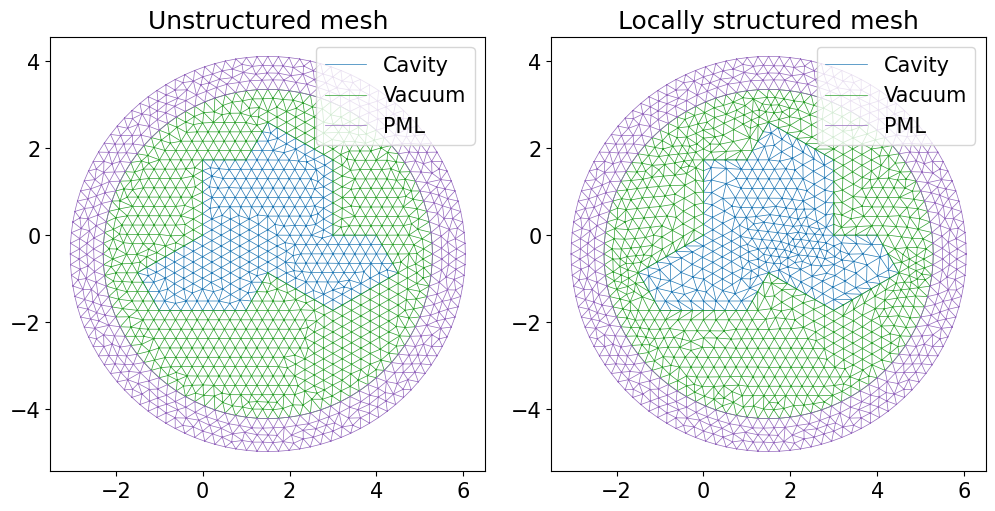

In [7]:
fig, axs = plt.subplots(ncols=2, figsize=[10, 5], layout="constrained")

axs[0].set_title("Unstructured mesh")
lsm.plot_mesh("mesh.msh", ax=axs[0])

axs[1].set_title("Locally structured mesh")
lsm.plot_mesh("mesh_lost.msh", ax=axs[1])